# [ Computer Vision ] [ CSE445 ] [ Assignment-2 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
!pip install ultralytics timm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 4.8 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import copy
import time
import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# partition splits
splits_dataset_dir = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition"
ssl_pool_dir    = os.path.join(splits_dataset_dir, "ssl_pool_images")
val_img_dir     = os.path.join(splits_dataset_dir, "yolo_rho20", "images", "val")
test_img_dir    = os.path.join(splits_dataset_dir, "yolo_rho20", "images", "test")
print("Partition dataset contents:", sorted(os.listdir(splits_dataset_dir)), "\n")

working_dir = "/kaggle/working/"
os.makedirs(working_dir, exist_ok=True)

METHOD     = "BYOL"
FAMILY     = "Self-Distillation"
ENCODER    = "YOLOv12s backbone"
BEST_YAML  = "yolo12s.yaml"

AUG_CFG = {
    "random_resized_crop_scale": (0.2, 1.0),
    "hflip_p": 0.5,
    "color_jitter": (0.4, 0.4, 0.4, 0.1),
    "color_jitter_p": 0.8,
    "grayscale_p": 0.2,
    "gaussian_blur_kernel": 23,
    "gaussian_blur_sigma": (0.1, 2.0),
}

SEED       = 42
IMGSZ_SSL  = 224
BATCH      = 16
EPOCHS     = 200
LR         = 3e-4
PROJ_HIDDEN = 4096
PROJ_DIM    = 256
PRED_HIDDEN = 4096
EMA_BASE    = 0.996

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("\n====== Configuration ======\n")
print("Method           :", METHOD)
print("Encoder          :", ENCODER)
print("Detector YAML    :", BEST_YAML)
print("SSL pool dir     :", ssl_pool_dir)
print("Device           :", device)
print("Seed             :", SEED)
print("Image size       :", IMGSZ_SSL)
print("Batch size       :", BATCH)
print("Epochs           :", EPOCHS)
print("LR               :", LR)
print("Projection dim   :", PROJ_DIM)
print("Projection hidden:", PROJ_HIDDEN)
print("Predictor hidden :", PRED_HIDDEN)
print("EMA base momentum:", EMA_BASE)
print("Mixed precision  : ON (AMP)")
print("\nAugmentation policy:")
for k, v in AUG_CFG.items():
    print(f"{k:28s}: {v}")

Partition dataset contents: ['__notebook__.ipynb', '__output__.json', '__results__.html', 'custom.css', 'splits', 'ssl_pool_images', 'yolo_rho20'] 


====== Configuration ======

Method           : BYOL
Encoder          : YOLOv12s backbone
Detector YAML    : yolo12s.yaml
SSL pool dir     : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition/ssl_pool_images
Device           : cuda
Seed             : 42
Image size       : 224
Batch size       : 16
Epochs           : 200
LR               : 0.0003
Projection dim   : 256
Projection hidden: 4096
Predictor hidden : 4096
EMA base momentum: 0.996
Mixed precision  : ON (AMP)

Augmentation policy:
random_resized_crop_scale   : (0.2, 1.0)
hflip_p                     : 0.5
color_jitter                : (0.4, 0.4, 0.4, 0.1)
color_jitter_p              : 0.8
grayscale_p                 : 0.2
gaussian_blur_kernel        : 23
gaussian_blur_sigma         : (0.1, 2.0)


In [3]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def stem_set(folder):
    names = set()
    for f in os.listdir(folder):
        if not f.lower().endswith(IMG_EXT):
            continue
        stem = f.split("__", 1)[1] if "__" in f else f
        names.add(os.path.splitext(stem)[0])
    return names

ssl_names  = stem_set(ssl_pool_dir)
val_names  = stem_set(val_img_dir)
test_names = stem_set(test_img_dir)
total = len(ssl_names) + len(val_names) + len(test_names)

print("Partition sizes (seed =", SEED, "):")
print(f"SSL pool     : {len(ssl_names):5d}  ({len(ssl_names)/total:6.2%})")
print(f"Validation   : {len(val_names):5d}  ({len(val_names)/total:6.2%})")
print(f"Test holdout : {len(test_names):5d}  ({len(test_names)/total:6.2%})")
print(f"TOTAL |D|    : {total:5d}")

print("\nDisjointness Check:")
i_ts = test_names & ssl_names
i_vs = val_names  & ssl_names
print(f"test ∩ ssl_pool : {len(i_ts)}  -> {'PASS' if not i_ts else 'FAIL'}")
print(f"val  ∩ ssl_pool : {len(i_vs)}  -> {'PASS' if not i_vs else 'FAIL'}")
assert not i_ts and not i_vs, "LEAKAGE"

Partition sizes (seed = 42 ):
SSL pool     :  2485  (79.98%)
Validation   :   311  (10.01%)
Test holdout :   311  (10.01%)
TOTAL |D|    :  3107

Disjointness Check:
test ∩ ssl_pool : 0  -> PASS
val  ∩ ssl_pool : 0  -> PASS


## Extract YOLO Backbone As Encoder

In [4]:
from ultralytics import YOLO
import timm

full = YOLO(BEST_YAML).model
n_bb = len(full.yaml["backbone"])
print("backbone layers:", n_bb)

try:
    backbone = nn.Sequential(*list(full.model[:n_bb]))

    dummy = torch.randn(1, 3, IMGSZ_SSL, IMGSZ_SSL)
    with torch.no_grad():
        out = backbone(dummy)
    print("nn.Sequential backbone worked. Output shape:", out.shape)
    USE_TIMM = False

except Exception as e:
    print("nn.Sequential backbone FAILED (Concat/routing bhenge geche):")
    print(" ", e)
    print("Falling back to timm encoder (ResNet18)")
    USE_TIMM = True

    timm_model = timm.create_model("resnet18", pretrained=False, num_classes=0, global_pool="")
    backbone = timm_model

    dummy = torch.randn(1, 3, IMGSZ_SSL, IMGSZ_SSL)
    with torch.no_grad():
        out = backbone(dummy)
    print("timm fallback backbone (ResNet18) ready. Output shape:", out.shape)
    print("NOTE: fallback encoder is architecturally different from the YOLO backbone —")
    print("      weight surgery into the detector in notebook 2b will need a compatible adapter/mapping,")
    print("      this must be documented in the report if this path is triggered.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
backbone layers: 9
nn.Sequential backbone worked. Output shape: torch.Size([1, 512, 7, 7])


## BYOL Model + Loss

In [5]:
ENC_DIM = out.shape[1]
print("Encoder output channels:", ENC_DIM)

class ProjectionHead(nn.Module):
    """Two-layer MLP with BatchNorm — used as both the projection head and the
    predictor head, per the BYOL paper."""
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class BYOL(nn.Module):
    def __init__(self, enc, dim=ENC_DIM, proj_hidden=PROJ_HIDDEN, proj_dim=PROJ_DIM, pred_hidden=PRED_HIDDEN):
        super().__init__()
        self.online_enc  = enc
        self.pool        = nn.AdaptiveAvgPool2d(1)
        self.online_proj = ProjectionHead(dim, proj_hidden, proj_dim)
        self.predictor   = ProjectionHead(proj_dim, pred_hidden, proj_dim)

        self.target_enc  = copy.deepcopy(self.online_enc)
        self.target_proj = copy.deepcopy(self.online_proj)
        for p in self.target_enc.parameters():
            p.requires_grad = False
        for p in self.target_proj.parameters():
            p.requires_grad = False

    def embed(self, enc, x):
        return self.pool(enc(x)).flatten(1)

    def forward(self, v1, v2):
        o1 = self.online_proj(self.embed(self.online_enc, v1))
        o2 = self.online_proj(self.embed(self.online_enc, v2))
        p1, p2 = self.predictor(o1), self.predictor(o2)
        with torch.no_grad():
            t1 = self.target_proj(self.embed(self.target_enc, v1))
            t2 = self.target_proj(self.embed(self.target_enc, v2))
        return p1, p2, t1.detach(), t2.detach()

    @torch.no_grad()
    def update_target(self, m):
        for po, pt in zip(self.online_enc.parameters(), self.target_enc.parameters()):
            pt.data = m * pt.data + (1 - m) * po.data
        for po, pt in zip(self.online_proj.parameters(), self.target_proj.parameters()):
            pt.data = m * pt.data + (1 - m) * po.data

def byol_loss(pred, target):
    pred = F.normalize(pred, dim=-1)
    target = F.normalize(target, dim=-1)
    return 2 - 2 * (pred * target).sum(dim=-1).mean()

def cosine_momentum(base, step, total_steps):
    return 1 - (1 - base) * (math.cos(math.pi * step / total_steps) + 1) / 2

model = BYOL(backbone).to(device)
optimizer = torch.optim.Adam(
    list(model.online_enc.parameters()) + list(model.online_proj.parameters()) + list(model.predictor.parameters()),
    lr=LR,
)

print("BYOL model ready. Params:", sum(p.numel() for p in model.parameters()))

Encoder output channels: 512
BYOL model ready. Params: 19319424


## Augmentation (2 Views) + Dataset

In [6]:
import torchvision.transforms as T

byol_aug = T.Compose([
    T.RandomResizedCrop(IMGSZ_SSL, scale=AUG_CFG["random_resized_crop_scale"]),
    T.RandomHorizontalFlip(p=AUG_CFG["hflip_p"]),
    T.RandomApply([T.ColorJitter(*AUG_CFG["color_jitter"])], p=AUG_CFG["color_jitter_p"]),
    T.RandomGrayscale(p=AUG_CFG["grayscale_p"]),
    T.GaussianBlur(kernel_size=AUG_CFG["gaussian_blur_kernel"],
                   sigma=AUG_CFG["gaussian_blur_sigma"]),
    T.ToTensor(),
])

class SSLDataset(Dataset):
    def __init__(self, root, transform):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        v1 = self.transform(img)
        v2 = self.transform(img)
        return v1, v2

dataset = SSLDataset(ssl_pool_dir, byol_aug)
loader = DataLoader(dataset, batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True)

print("SSL pool images:", len(dataset))
print("Batches per epoch:", len(loader))

SSL pool images: 2485
Batches per epoch: 155


## Sanity Check — Two Augmented Views Of One Image

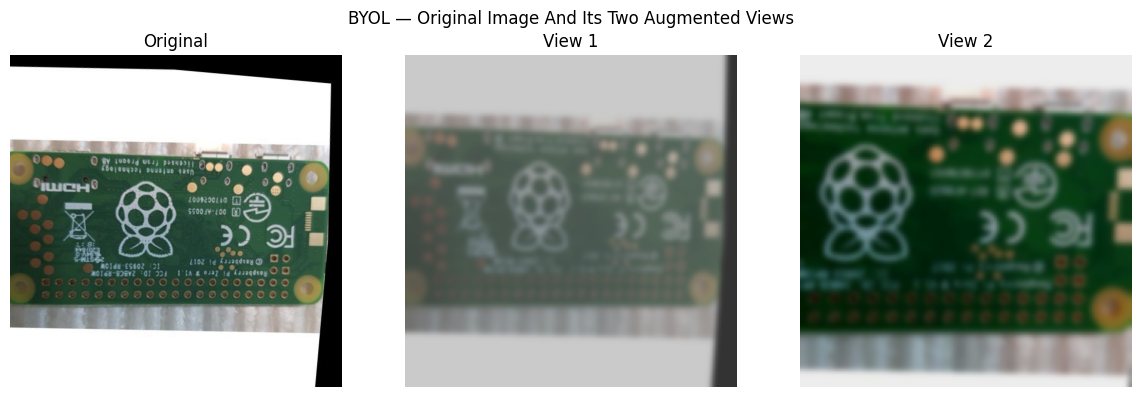

In [7]:
sample_path = dataset.paths[0]
sample_original = Image.open(sample_path).convert("RGB")
sample_v1, sample_v2 = dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sample_v1.permute(1, 2, 0))
axes[1].set_title("View 1")
axes[1].axis("off")

axes[2].imshow(sample_v2.permute(1, 2, 0))
axes[2].set_title("View 2")
axes[2].axis("off")

plt.suptitle("BYOL — Original Image And Its Two Augmented Views")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "byol_two_views.png"), dpi=150)
plt.show()

## Train BYOL (200 Epochs, AMP)

In [8]:
scaler = torch.amp.GradScaler("cuda")
loss_history = []
total_steps = EPOCHS * len(loader)
step = 0

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for v1, v2 in loader:
        v1, v2 = v1.to(device), v2.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            p1, p2, t1, t2 = model(v1, v2)
            loss = byol_loss(p1, t2) + byol_loss(p2, t1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        m = cosine_momentum(EMA_BASE, step, total_steps)
        model.update_target(m)

        epoch_loss += loss.item()
        step += 1

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss: {avg_loss:.4f}  momentum: {m:.5f}")

Epoch   1/200  loss: 1.5179  momentum: 0.99600
Epoch   2/200  loss: 1.9216  momentum: 0.99600
Epoch   3/200  loss: 1.6433  momentum: 0.99600
Epoch   4/200  loss: 1.1349  momentum: 0.99600
Epoch   5/200  loss: 0.8981  momentum: 0.99601
Epoch   6/200  loss: 0.7962  momentum: 0.99601
Epoch   7/200  loss: 0.7644  momentum: 0.99601
Epoch   8/200  loss: 0.7577  momentum: 0.99602
Epoch   9/200  loss: 0.8295  momentum: 0.99602
Epoch  10/200  loss: 0.8488  momentum: 0.99602
Epoch  11/200  loss: 0.8293  momentum: 0.99603
Epoch  12/200  loss: 0.8430  momentum: 0.99604
Epoch  13/200  loss: 0.7682  momentum: 0.99604
Epoch  14/200  loss: 0.8155  momentum: 0.99605
Epoch  15/200  loss: 0.8063  momentum: 0.99606
Epoch  16/200  loss: 0.7840  momentum: 0.99606
Epoch  17/200  loss: 0.6838  momentum: 0.99607
Epoch  18/200  loss: 0.7057  momentum: 0.99608
Epoch  19/200  loss: 0.6988  momentum: 0.99609
Epoch  20/200  loss: 0.6793  momentum: 0.99610
Epoch  21/200  loss: 0.6204  momentum: 0.99611
Epoch  22/200

## Loss Curve

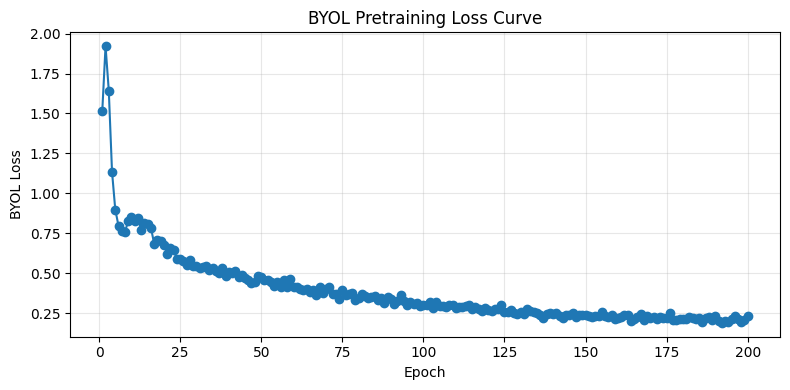

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BYOL Loss")
plt.title("BYOL Pretraining Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "byol_loss_curve.png"), dpi=150)
plt.show()

## Embedding Visualization: t-SNE + Top-5 Nearest Neighbor Retrieval

Validation embeddings shape: (311, 512)


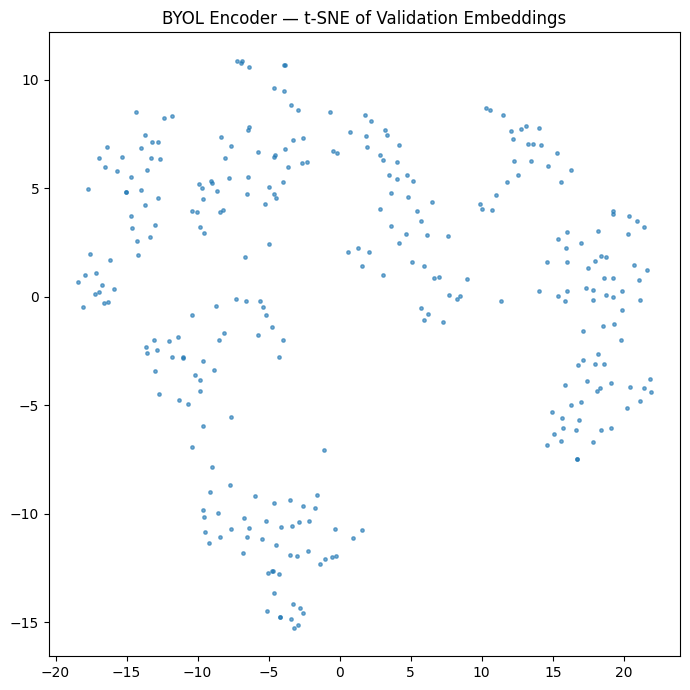

In [10]:
from sklearn.manifold import TSNE

eval_transform = T.Compose([
    T.Resize((IMGSZ_SSL, IMGSZ_SSL)),
    T.ToTensor(),
])

eval_dataset = SSLDataset(val_img_dir, eval_transform)
model.eval()

all_embeddings = []
all_paths = []

with torch.no_grad():
    for i in range(len(eval_dataset)):
        img = Image.open(eval_dataset.paths[i]).convert("RGB")
        x = eval_transform(img).unsqueeze(0).to(device)
        h = model.embed(model.online_enc, x)
        all_embeddings.append(h.cpu().numpy()[0])
        all_paths.append(eval_dataset.paths[i])

all_embeddings = np.array(all_embeddings)
print("Validation embeddings shape:", all_embeddings.shape)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
emb_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(7, 7))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=6, alpha=0.6)
plt.title("BYOL Encoder — t-SNE of Validation Embeddings")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "byol_tsne.png"), dpi=150)
plt.show()

## Top-5 nearest-neighbor

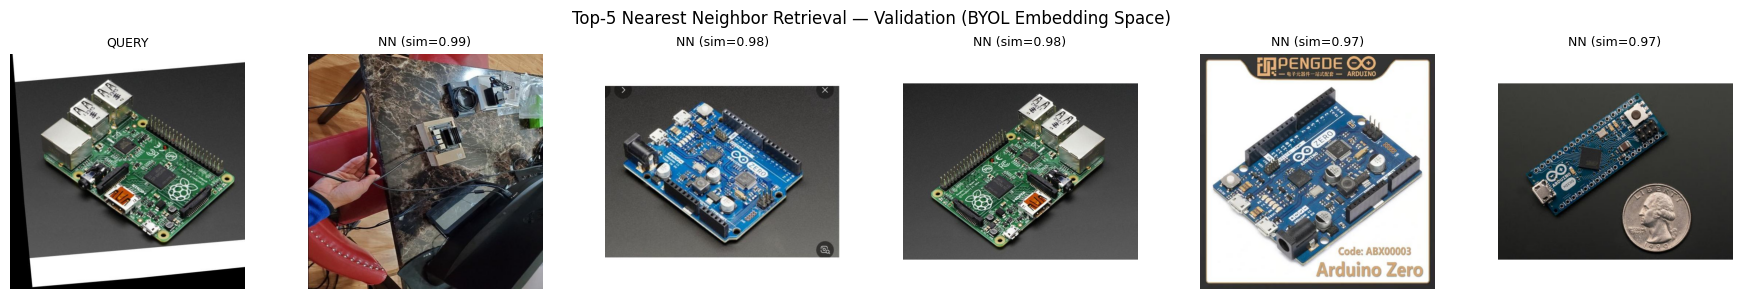

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

query_idx = 0
sims = cosine_similarity([all_embeddings[query_idx]], all_embeddings)[0]
top6 = np.argsort(-sims)[:6]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, idx in zip(axes, top6):
    img = Image.open(all_paths[idx]).convert("RGB")
    ax.imshow(img)
    tag = "QUERY" if idx == query_idx else f"NN (sim={sims[idx]:.2f})"
    ax.set_title(tag, fontsize=9)
    ax.axis("off")

plt.suptitle("Top-5 Nearest Neighbor Retrieval — Validation (BYOL Embedding Space)")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "byol_retrieval_panel.png"), dpi=150)
plt.show()

## Save Best Checkpoint

In [12]:
ckpt_path = os.path.join(working_dir, "byol_backbone.pt")
torch.save(model.online_enc.state_dict(), ckpt_path)
print("BYOL backbone saved:", ckpt_path)

BYOL backbone saved: /kaggle/working/byol_backbone.pt
